In [29]:
%pip install sympy casadi matplotlib scipy pandas -q

Note: you may need to restart the kernel to use updated packages.


# 3a

In [30]:
import sympy as sp
import numpy as np
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.linalg import expm
import pandas as pd


In [3]:

class RoverModel:
    def __init__(self):
        self.t = sp.symbols("t", real=True)
        self.Delta_t = sp.symbols("dt", positive=True, real=True)

        self.T_fig8 = sp.symbols("T_fig8", positive=True, real=True)
        self.T_lobe = sp.symbols("T_lobe", positive=True, real=True)
        self.omega_turn = sp.symbols("omega_turn", real=True)

        # true state
        x, y, theta = sp.symbols("x y theta", real=True)
        self.x = sp.Matrix([x, y, theta])

        # reference state
        xhat, yhat, thetahat = sp.symbols("xhat yhat thetahat", real=True)
        self.xhat = sp.Matrix([xhat, yhat, thetahat])

        # body-frame error
        ex, ey, eth = sp.symbols("e_x e_y e_theta", real=True)
        self.eps = sp.Matrix([ex, ey, eth])

        # commanded inputs for derivation
        self.v_cmd = sp.symbols("v_cmd", real=True)
        self.omega_cmd = sp.symbols("omega_cmd", real=True)

        # process noise (actuator-noise form)
        w_v, w_omega = sp.symbols("w_v w_omega", real=True)
        self.w = sp.Matrix([w_v, w_omega])

        # measurement noise
        v_x, v_y = sp.symbols("v_x v_y", real=True)
        self.v = sp.Matrix([v_x, v_y])

        # covariance symbols
        P11, P12, P13, P21, P22, P23, P31, P32, P33 = sp.symbols(
            "P11 P12 P13 P21 P22 P23 P31 P32 P33", real=True
        )
        self.P = sp.Matrix([
            [P11, P12, P13],
            [P21, P22, P23],
            [P31, P32, P33]
        ])

        sigma_gps = sp.symbols("sigma_GPS", positive=True, real=True)
        self.R = sp.diag(sigma_gps**2, sigma_gps**2)

    def omega_ref_expr(self):
        tau = sp.Mod(self.t, self.T_fig8)
        return sp.Piecewise(
            (self.omega_turn, tau < self.T_lobe),
            (-self.omega_turn, True)
        )

    def R2(self, angle):
        c = sp.cos(angle)
        s = sp.sin(angle)
        return sp.Matrix([
            [c, -s],
            [s,  c]
        ])

    def discrete_dynamics_with_cmd(self, x_state, v_cmd, omega_cmd, w_noise=None):
        if w_noise is None:
            w_noise = sp.Matrix([0, 0])

        theta = x_state[2]
        w_v, w_omega = w_noise
        v_total = v_cmd + w_v
        omega_total = omega_cmd + w_omega
        phi = omega_total * self.Delta_t
        travel = self.Delta_t * v_total * sp.sinc(phi / 2)
        theta_mid = theta + phi / 2

        return sp.Matrix([
            x_state[0] + travel * sp.cos(theta_mid),
            x_state[1] + travel * sp.sin(theta_mid),
            x_state[2] + phi
        ])

    def body_error_definition(self, x_true, x_ref):
        p_true = x_true[:2, 0]
        p_ref = x_ref[:2, 0]
        theta_ref = x_ref[2]

        e_pos = self.R2(theta_ref).T * (p_true - p_ref)
        e_theta = x_true[2] - theta_ref

        return sp.Matrix([e_pos[0], e_pos[1], e_theta])

    def true_state_from_reference_and_error(self, x_ref, eps):
        p_ref = x_ref[:2, 0]
        theta_ref = x_ref[2]

        p_true = p_ref + self.R2(theta_ref) * eps[:2, 0]
        theta_true = theta_ref + eps[2]

        return sp.Matrix([p_true[0], p_true[1], theta_true])

    def exact_body_error_next(self):
        x_true_k = self.true_state_from_reference_and_error(self.xhat, self.eps)

        x_true_k1 = self.discrete_dynamics_with_cmd(
            x_true_k, self.v_cmd, self.omega_cmd, self.w
        )
        xhat_k1 = self.discrete_dynamics_with_cmd(
            self.xhat, self.v_cmd, self.omega_cmd, sp.Matrix([0, 0])
        )

        eps_k1 = self.body_error_definition(x_true_k1, xhat_k1)
        return sp.simplify(eps_k1)

    def body_error_jacobians(self):
        eps_next = self.exact_body_error_next()

        A = eps_next.jacobian(self.eps)
        G_w = eps_next.jacobian(self.w)

        lin_point = {
            self.eps[0]: 0,
            self.eps[1]: 0,
            self.eps[2]: 0,
            self.w[0]: 0,
            self.w[1]: 0,
        }

        A_lin = sp.simplify(A.subs(lin_point))
        G_w_lin = sp.simplify(G_w.subs(lin_point))
        return A_lin, G_w_lin

    # Measurement model in body-frame error coordinates:
    # z_k ≈ p_hat_k + R_hat_k [e_x, e_y]^T + v_k
    def gps_measurement_body_frame(self, eps=None):
        if eps is None:
            eps = self.eps

        p_hat = self.xhat[:2, 0]
        R_hat = self.R2(self.xhat[2])

        return p_hat + R_hat @ eps[:2, 0] + self.v

    # H_k = [R_hat  0]
    def H_k_body_frame(self):
        R_hat = self.R2(self.xhat[2])
        zero_col = sp.Matrix([[0], [0]])
        return R_hat.row_join(zero_col)

    def innovation_covariance(self, P=None):
        if P is None:
            P = self.P
        H = self.H_k_body_frame()
        return sp.simplify(H @ P @ H.T + self.R)

    def kalman_gain(self, P=None):
        if P is None:
            P = self.P
        H = self.H_k_body_frame()
        S = self.innovation_covariance(P)
        return sp.simplify(P @ H.T @ S.inv())

    def covariance_update_joseph(self, P=None):
        if P is None:
            P = self.P
        H = self.H_k_body_frame()
        K = self.kalman_gain(P)
        I = sp.eye(3)
        return sp.simplify((I - K @ H) @ P @ (I - K @ H).T + K @ self.R @ K.T)

In [4]:
model = RoverModel()
A_lin, G_w_lin = model.body_error_jacobians()


In [5]:
A_lin

Matrix([
[ cos(dt*omega_cmd), sin(dt*omega_cmd), dt*v_cmd*sin(dt*omega_cmd)],
[-sin(dt*omega_cmd), cos(dt*omega_cmd), dt*v_cmd*cos(dt*omega_cmd)],
[                 0,                 0,                          1]])

In [6]:
G_w_lin

Matrix([
[ dt*cos(dt*omega_cmd),  0],
[-dt*sin(dt*omega_cmd),  0],
[                    0, dt]])

# 3b

Process noise is defined in the robot’s body frame, and the error state εk is also expressed in the same frame. Therefore, no coordinate transformation is required, and the covariance is simply Q = del_t^2 * Q_body

In contrast, a world-frame EKF represents the state in global coordinates, so body-frame noise must be rotated into the world frame, making Qk depend on the vehicle orientation (heading)

# 3c

In [7]:
model = RoverModel()

z_model = model.gps_measurement_body_frame()
Hk = model.H_k_body_frame()
S = model.innovation_covariance()
K = model.kalman_gain()
P_corr = model.covariance_update_joseph()


print("\nz_k model:")
sp.pprint(z_model)

print("\nH_k:")
sp.pprint(Hk)

print("\nS_k:")
sp.pprint(S)

print("\nK_k:")
sp.pprint(K)

print("\nJoseph covariance update:")
sp.pprint(P_corr)


z_k model:
⎡eₓ⋅cos(θ̂) - e_y⋅sin(θ̂) + vₓ + x̂ ⎤
⎢                                ⎥
⎣eₓ⋅sin(θ̂) + e_y⋅cos(θ̂) + v_y + ŷ⎦

H_k:
⎡cos(θ̂)  -sin(θ̂)  0⎤
⎢                  ⎥
⎣sin(θ̂)  cos(θ̂)   0⎦

S_k:
⎡P₁₁⋅cos(2⋅θ̂)   P₁₁   P₁₂⋅sin(2⋅θ̂)   P₂₁⋅sin(2⋅θ̂)   P₂₂⋅cos(2⋅θ̂)   P₂₂         ↪
⎢──────────── + ─── - ──────────── - ──────────── - ──────────── + ─── + σ_GPS ↪
⎢     2          2         2              2              2          2          ↪
⎢                                                                              ↪
⎢    P₁₁⋅sin(2⋅θ̂)   P₁₂⋅cos(2⋅θ̂)   P₁₂   P₂₁⋅cos(2⋅θ̂)   P₂₁   P₂₂⋅sin(2⋅θ̂)     ↪
⎢    ──────────── + ──────────── - ─── + ──────────── + ─── - ────────────     ↪
⎣         2              2          2         2          2         2           ↪

↪ 2       P₁₁⋅sin(2⋅θ̂)   P₁₂⋅cos(2⋅θ̂)   P₁₂   P₂₁⋅cos(2⋅θ̂)   P₂₁   P₂₂⋅sin(2⋅θ̂ ↪
↪         ──────────── + ──────────── + ─── + ──────────── - ─── - ─────────── ↪
↪              2              2          2         2    

# 3d

In [8]:
# Initial conditions
x_true = np.array([0.0, 0.0, 0.0], dtype=float)   # true world state
xhat   = np.array([0.0, 0.0, 0.0], dtype=float)   # nominal/reference world state
P      = 0.01 * np.eye(3)                         # body-frame error covariance

dt = 0.1
T = 35.0
N = int(T / dt)

# parameters
v_nom = 2.0
omega_turn = 0.4
T_lobe = 2 * np.pi / omega_turn
T_fig8 = 2 * T_lobe

sigma_v = 1.0
sigma_omega = 0.05
sigma_GPS = 0.3

# this means one GPS update every 1 second when dt = 0.1
gps_rate = int(1 / dt)

# covariances
Q_body = np.diag([sigma_v**2, 0.0, sigma_omega**2])
R_gps  = sigma_GPS**2 * np.eye(2)

# history
x_true_hist = []
xhat_hist   = []
P_hist      = []
gps_hist    = []
nees_hist   = []
nis_hist    = []

def omega_ref(t):
    tau = np.mod(t, T_fig8)
    if tau < T_lobe:
        return omega_turn
    else:
        return -omega_turn

def wrap_angle(a):
    return (a + np.pi) % (2 * np.pi) - np.pi

def exact_unicycle_step(state, v_cmd, omega_cmd, dt):
    x, y, theta = np.asarray(state, dtype=float)
    phi = omega_cmd * dt
    travel = dt * v_cmd * np.sinc(phi / (2.0 * np.pi))
    theta_mid = theta + 0.5 * phi
    return np.array([
        x + travel * np.cos(theta_mid),
        y + travel * np.sin(theta_mid),
        theta + phi
    ], dtype=float)

def body_error_A_exact(v, omega, dt):
    A_c = np.array([
        [0.0, omega, 0.0],
        [-omega, 0.0, v],
        [0.0, 0.0, 0.0]
    ], dtype=float)
    return expm(A_c * dt)

for k in range(N):
    t = k * dt

    # commanded input
    u = [v_nom, omega_ref(t)]

    # --- True system ---
    w_v = np.random.randn() * sigma_v
    w_omega = np.random.randn() * sigma_omega

    x_true = exact_unicycle_step(x_true, u[0] + w_v, u[1] + w_omega, dt)
    x_true[2] = wrap_angle(x_true[2])

    # --- GPS measurement ---
    if k % gps_rate == 0:
        v_meas = np.random.randn(2) * sigma_GPS
        y = x_true[:2] + v_meas
    else:
        y = None

    # --- Predict nominal/reference state ---
    x_pred = exact_unicycle_step(xhat, u[0], u[1], dt)
    x_pred[2] = wrap_angle(x_pred[2])

    # --- Predict covariance in body-frame error coordinates ---
    A_k = body_error_A_exact(u[0], u[1], dt)

    G = dt * np.eye(3)
    P_pred = A_k @ P @ A_k.T + G @ Q_body @ G.T
    P_pred = 0.5 * (P_pred + P_pred.T)

    # --- NIS + Correct ---
    if y is not None:
        c = np.cos(x_pred[2])
        s = np.sin(x_pred[2])

        # H_k = [R_hat  0]
        H_k = np.array([
            [c, -s, 0.0],
            [s,  c, 0.0]
        ])

        # predicted GPS measurement is nominal world position
        z_hat = x_pred[:2]

        innovation = y - z_hat
        S = H_k @ P_pred @ H_k.T + R_gps
        K = P_pred @ H_k.T @ np.linalg.inv(S)

        nis = innovation.T @ np.linalg.inv(S) @ innovation

        # estimated body-frame correction
        delta_eps = K @ innovation
        dx_b, dy_b, dtheta = delta_eps

        # inject body-frame correction into nominal/reference world pose
        xhat = x_pred.copy()
        xhat[0] = x_pred[0] + c * dx_b - s * dy_b
        xhat[1] = x_pred[1] + s * dx_b + c * dy_b
        xhat[2] = wrap_angle(x_pred[2] + dtheta)

        # reset error to zero; covariance update
        I = np.eye(3)
        P = (I - K @ H_k) @ P_pred @ (I - K @ H_k).T + K @ R_gps @ K.T
        P = 0.5 * (P + P.T)
    else:
        nis = np.nan
        xhat = x_pred
        P = P_pred

    # --- NEES ---
    # error must be expressed in body frame because P is body-frame covariance
    c = np.cos(xhat[2])
    s = np.sin(xhat[2])
    R_hat = np.array([
        [c, -s],
        [s,  c]
    ])

    pos_err_world = x_true[:2] - xhat[:2]
    pos_err_body = R_hat.T @ pos_err_world
    theta_err = wrap_angle(x_true[2] - xhat[2])

    err = np.array([pos_err_body[0], pos_err_body[1], theta_err])
    nees = err.T @ np.linalg.inv(P) @ err

    # --- Store ---
    x_true_hist.append(x_true.copy())
    xhat_hist.append(xhat.copy())
    P_hist.append(P.copy())          # body-frame covariance
    gps_hist.append(y)
    nees_hist.append(nees)
    nis_hist.append(nis)

x_true_hist = np.array(x_true_hist)
xhat_hist = np.array(xhat_hist)
P_hist = np.array(P_hist)
nees_hist = np.array(nees_hist)
nis_hist = np.array(nis_hist)

# 3e

In [9]:
P_world_hist = []

for k in range(N):
    theta = xhat_hist[k, 2]
    c = np.cos(theta)
    s = np.sin(theta)

    R_hat = np.array([
        [c, -s],
        [s,  c]
    ])

    T_bw = np.block([
        [R_hat, np.zeros((2, 1))],
        [np.zeros((1, 2)), np.array([[1.0]])]
    ])

    P_world = T_bw @ P_hist[k] @ T_bw.T
    P_world_hist.append(P_world)

P_world_hist = np.array(P_world_hist)

In [10]:
def plot_cov_ellipse(P_xy, center, ax, n_std=2.0, **kwargs):
    vals, vecs = np.linalg.eigh(P_xy)
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width = 2 * n_std * np.sqrt(vals[0])
    height = 2 * n_std * np.sqrt(vals[1])

    ell = Ellipse(
        xy=center,
        width=width,
        height=height,
        angle=angle,
        fill=False,
        **kwargs
    )
    ax.add_patch(ell)

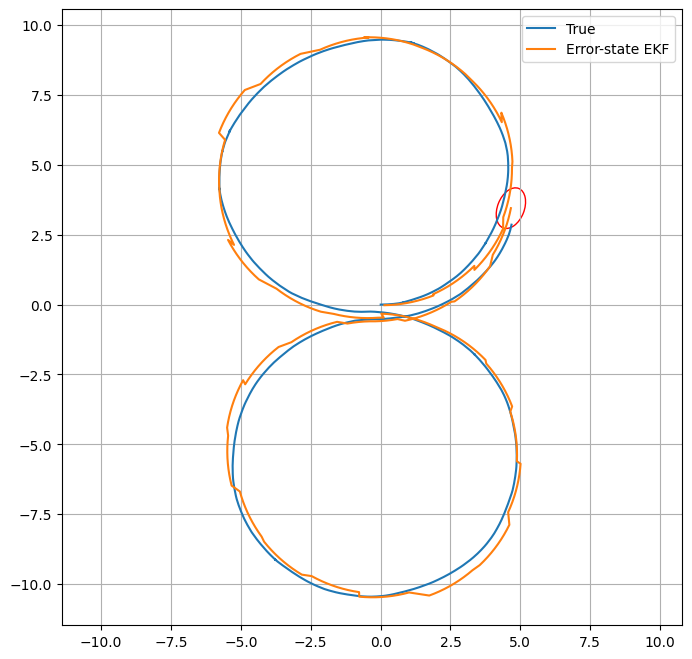

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(x_true_hist[:, 0], x_true_hist[:, 1], label="True")
ax.plot(xhat_hist[:, 0], xhat_hist[:, 1], label="Error-state EKF")
plot_cov_ellipse(P_world_hist[k][:2, :2], xhat_hist[k][:2], ax, n_std=2, color='r')
ax.axis('equal')
ax.grid(True)
ax.legend()
plt.show()

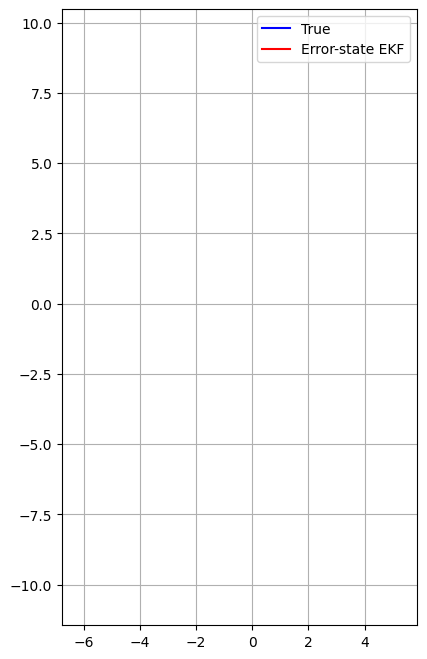

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.set_xlim(np.min(x_true_hist[:, 0]) - 1, np.max(x_true_hist[:, 0]) + 1)
ax.set_ylim(np.min(x_true_hist[:, 1]) - 1, np.max(x_true_hist[:, 1]) + 1)
ax.set_aspect('equal')
ax.grid(True)

true_line, = ax.plot([], [], 'b-', label='True')
est_line, = ax.plot([], [], 'r-', label='Error-state EKF')
point_est, = ax.plot([], [], 'ro')

ellipse = Ellipse((0, 0), 0, 0, angle=0, fill=False, color='r')
ax.add_patch(ellipse)

ax.legend()

def init():
    true_line.set_data([], [])
    est_line.set_data([], [])
    point_est.set_data([], [])
    ellipse.set_center((0, 0))
    ellipse.width = 0
    ellipse.height = 0
    ellipse.angle = 0
    return true_line, est_line, point_est, ellipse

def update(k):
    true_line.set_data(x_true_hist[:k+1, 0], x_true_hist[:k+1, 1])
    est_line.set_data(xhat_hist[:k+1, 0], xhat_hist[:k+1, 1])

    x = xhat_hist[k, 0]
    y = xhat_hist[k, 1]
    point_est.set_data([x], [y])

    P_xy = P_world_hist[k][:2, :2]

    vals, vecs = np.linalg.eigh(P_xy)
    vals = np.maximum(vals, 0.0)
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width = 4 * np.sqrt(vals[0])   # 2-sigma => diameter = 4*sqrt(lambda)
    height = 4 * np.sqrt(vals[1])

    ellipse.set_center((x, y))
    ellipse.width = width
    ellipse.height = height
    ellipse.angle = angle

    return true_line, est_line, point_est, ellipse

anim = FuncAnimation(
    fig,
    update,
    frames=len(x_true_hist),
    init_func=init,
    interval=50,
    blit=False
)

plt.show()

In [13]:
anim.save("3_bf_ekf_animation.gif", writer="pillow", fps=20)

The error-state EKF ellipse usually aligns much better with the vehicle’s forward direction than the world-frame EKF ellipse. That happens because the covariance is propagated in body-frame coordinates, where the process noise is naturally forward/lateral/angular, and then rotated into the world frame only for plotting. This is a better local approximation of the true banana-shaped uncertainty, since the spread mainly grows along the vehicle’s motion direction and curves with the trajectory rather than staying tied to fixed world axes.

# 3f

In [14]:
from scipy.stats import chi2

M = 100
nx = 3
nz = 2

nees_all_bf = np.zeros((M, N))
nis_all_bf = np.full((M, N), np.nan)

for m in range(M):
    # initial conditions
    x_true = np.array([0.0, 0.0, 0.0], dtype=float)
    xhat   = np.array([0.0, 0.0, 0.0], dtype=float)
    P      = 0.01 * np.eye(3)

    for k in range(N):
        t = k * dt
        u = [v_nom, omega_ref(t)]

        # --- True system ---
        w_v = np.random.randn() * sigma_v
        w_omega = np.random.randn() * sigma_omega

        x_true = exact_unicycle_step(x_true, u[0] + w_v, u[1] + w_omega, dt)
        x_true[2] = wrap_angle(x_true[2])

        # --- GPS measurement ---
        if k % gps_rate == 0:
            v_meas = np.random.randn(2) * sigma_GPS
            y = x_true[:2] + v_meas
        else:
            y = None

        # --- Predict nominal/reference state ---
        x_pred = exact_unicycle_step(xhat, u[0], u[1], dt)
        x_pred[2] = wrap_angle(x_pred[2])

        # --- Predict covariance in body-frame error coordinates ---
        A_k = body_error_A_exact(u[0], u[1], dt)

        G = dt * np.eye(3)
        P_pred = A_k @ P @ A_k.T + G @ Q_body @ G.T
        P_pred = 0.5 * (P_pred + P_pred.T)

        # --- Update ---
        if y is not None:
            c = np.cos(x_pred[2])
            s = np.sin(x_pred[2])

            H_k = np.array([
                [c, -s, 0.0],
                [s,  c, 0.0]
            ])

            z_hat = x_pred[:2]
            innovation = y - z_hat

            S = H_k @ P_pred @ H_k.T + R_gps
            K = P_pred @ H_k.T @ np.linalg.inv(S)

            nis = innovation.T @ np.linalg.inv(S) @ innovation
            nis_all_bf[m, k] = nis

            delta_eps = K @ innovation
            dx_b, dy_b, dtheta = delta_eps

            xhat = x_pred.copy()
            xhat[0] = x_pred[0] + c * dx_b - s * dy_b
            xhat[1] = x_pred[1] + s * dx_b + c * dy_b
            xhat[2] = wrap_angle(x_pred[2] + dtheta)

            I = np.eye(3)
            P = (I - K @ H_k) @ P_pred @ (I - K @ H_k).T + K @ R_gps @ K.T
            P = 0.5 * (P + P.T)
        else:
            xhat = x_pred
            P = P_pred

        # --- NEES in body frame ---
        c = np.cos(xhat[2])
        s = np.sin(xhat[2])
        R_hat = np.array([
            [c, -s],
            [s,  c]
        ])

        pos_err_world = x_true[:2] - xhat[:2]
        pos_err_body = R_hat.T @ pos_err_world
        theta_err = wrap_angle(x_true[2] - xhat[2])

        err_body = np.array([pos_err_body[0], pos_err_body[1], theta_err])
        nees = err_body.T @ np.linalg.inv(P) @ err_body
        nees_all_bf[m, k] = nees

In [15]:
nees_avg_bf = np.mean(nees_all_bf, axis=0)
nis_avg_bf = np.nanmean(nis_all_bf, axis=0)

nees_lo = chi2.ppf(0.025, M * nx) / M
nees_hi = chi2.ppf(0.975, M * nx) / M

valid_nis_counts = np.sum(~np.isnan(nis_all_bf), axis=0)
nis_lo_bf = np.full(N, np.nan)
nis_hi_bf = np.full(N, np.nan)

for k in range(N):
    if valid_nis_counts[k] > 0:
        nis_lo_bf[k] = chi2.ppf(0.025, valid_nis_counts[k] * nz) / valid_nis_counts[k]
        nis_hi_bf[k] = chi2.ppf(0.975, valid_nis_counts[k] * nz) / valid_nis_counts[k]

t_arr = np.arange(N) * dt

/tmp/ipykernel_12127/2365528138.py:2: RuntimeWarning: Mean of empty slice
  nis_avg_bf = np.nanmean(nis_all_bf, axis=0)


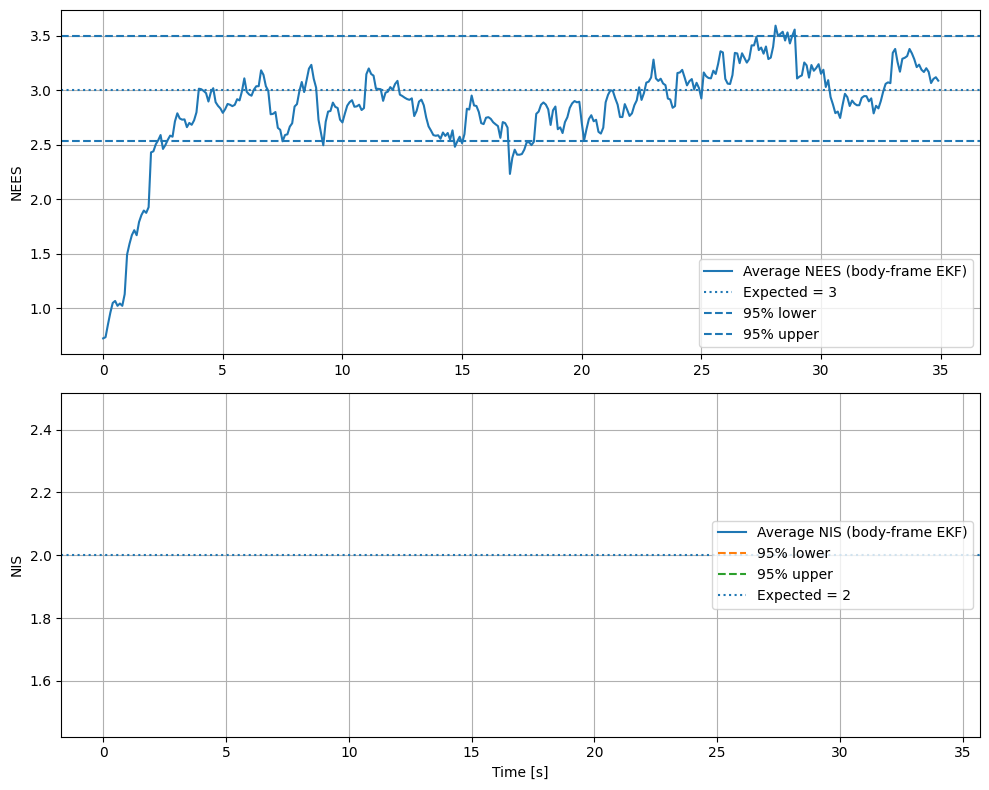

In [16]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(t_arr, nees_avg_bf, label='Average NEES (body-frame EKF)')
plt.axhline(nx, linestyle=':', label='Expected = 3')
plt.axhline(nees_lo, linestyle='--', label='95% lower')
plt.axhline(nees_hi, linestyle='--', label='95% upper')
plt.ylabel('NEES')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t_arr, nis_avg_bf, label='Average NIS (body-frame EKF)')
plt.plot(t_arr, nis_lo_bf, '--', label='95% lower')
plt.plot(t_arr, nis_hi_bf, '--', label='95% upper')
plt.axhline(nz, linestyle=':', label='Expected = 2')
plt.ylabel('NIS')
plt.xlabel('Time [s]')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

For NEES and NIS, the body-frame error-state EKF is typically more consistent than the world-frame EKF. Its average NEES usually stays closer to the expected value and within the 95% consistency bounds more often, which means its state covariance matches the true estimation error better.

# 4 a


In [17]:
def wrap_angle(a):
    return (a + np.pi) % (2 * np.pi) - np.pi

def exact_unicycle_step(state, v_cmd, omega_cmd, dt):
    x, y, theta = np.asarray(state, dtype=float)
    phi = omega_cmd * dt
    travel = dt * v_cmd * np.sinc(phi / (2.0 * np.pi))
    theta_mid = theta + 0.5 * phi
    return np.array([
        x + travel * np.cos(theta_mid),
        y + travel * np.sin(theta_mid),
        theta + phi
    ], dtype=float)

def body_error_A_exact(v, omega, dt):
    A_c = np.array([
        [0.0, omega, 0.0],
        [-omega, 0.0, v],
        [0.0, 0.0, 0.0]
    ], dtype=float)
    return expm(A_c * dt)

def iekf_Ac(v, omega):
    return np.array([
        [0.0,  omega, 0.0],
        [-omega, 0.0, v],
        [0.0, 0.0, 0.0]
    ], dtype=float)

def iekf_A_exact(v, omega, dt):
    # Exact discrete propagation:
    # A_k = Ad_{Exp(-xi^ dt)} = exp(A_c dt)
    Ac = iekf_Ac(v, omega)
    return expm(Ac * dt)

def iekf_A_first_order(v, omega, dt):
    return np.eye(3) + iekf_Ac(v, omega) * dt

In [ ]:
def wrap_angle(a):
    return (a + np.pi) % (2 * np.pi) - np.pi

def exact_unicycle_step(state, v_cmd, omega_cmd, dt):
    x, y, theta = np.asarray(state, dtype=float)
    phi = omega_cmd * dt
    travel = dt * v_cmd * np.sinc(phi / (2.0 * np.pi))
    theta_mid = theta + 0.5 * phi
    return np.array([
        x + travel * np.cos(theta_mid),
        y + travel * np.sin(theta_mid),
        theta + phi
    ], dtype=float)

def body_error_A_exact(v, omega, dt):
    A_c = np.array([
        [0.0, omega, 0.0],
        [-omega, 0.0, v],
        [0.0, 0.0, 0.0]
    ], dtype=float)
    return expm(A_c * dt)

def iekf_Ac(v, omega):
    return np.array([
        [0.0,  omega, 0.0],
        [-omega, 0.0, v],
        [0.0, 0.0, 0.0]
    ], dtype=float)

def iekf_A_exact(v, omega, dt):
    # Exact discrete propagation:
    # A_k = Ad_{Exp(-xi^ dt)} = exp(A_c dt)
    Ac = iekf_Ac(v, omega)
    return expm(Ac * dt)

def iekf_A_first_order(v, omega, dt):
    return np.eye(3) + iekf_Ac(v, omega) * dt

# 4a

In [18]:
v_test = v_nom
omega_test = omega_turn

Ac = iekf_Ac(v_test, omega_test)
Ak_exact = iekf_A_exact(v_test, omega_test, dt)
Ak_fo = iekf_A_first_order(v_test, omega_test, dt)

print("A_c =")
print(Ac)

print("\nA_k exact =")
print(Ak_exact)

print("\nA_k first-order =")
print(Ak_fo)

A_c =
[[ 0.   0.4  0. ]
 [-0.4  0.   2. ]
 [ 0.   0.   0. ]]

A_k exact =
[[ 0.99920011  0.03998933  0.00399947]
 [-0.03998933  0.99920011  0.19994667]
 [ 0.          0.          1.        ]]

A_k first-order =
[[ 1.    0.04  0.  ]
 [-0.04  1.    0.2 ]
 [ 0.    0.    1.  ]]


The IEKF error dynamics are derived from the group structure of SE(2), not from a direct Taylor expansion in coordinates. Because of that, the linearized matrix Ak depends only on the commanded body velocity (v^,ω^) and not on the current pose, which makes the filter more geometrically consistent. The covariance prediction is the same form as in Problem 3, but now the state-independence of Ak is guaranteed by the Lie-group derivation.

# 4b and 4c

In [21]:
# IEKF single-run implementation

x_true = np.array([0.0, 0.0, 0.0], dtype=float)
xhat   = np.array([0.0, 0.0, 0.0], dtype=float)
P      = 0.01 * np.eye(3)

Q_body = np.diag([sigma_v**2, 0.0, sigma_omega**2])
R_gps  = sigma_GPS**2 * np.eye(2)

x_true_hist = []
xhat_hist   = []
P_hist      = []
gps_hist    = []
nees_hist   = []
nis_hist    = []

for k in range(N):
    t = k * dt
    u = [v_nom, omega_ref(t)]

    # true system
    w_v = np.random.randn() * sigma_v
    w_omega = np.random.randn() * sigma_omega

    x_true = exact_unicycle_step(x_true, u[0] + w_v, u[1] + w_omega, dt)
    x_true[2] = wrap_angle(x_true[2])

    # GPS
    if k % gps_rate == 0:
        v_meas = np.random.randn(2) * sigma_GPS
        y = x_true[:2] + v_meas
    else:
        y = None

    # nominal prediction
    x_pred = exact_unicycle_step(xhat, u[0], u[1], dt)
    x_pred[2] = wrap_angle(x_pred[2])

    # IEKF covariance prediction
    A_k = iekf_A_exact(u[0], u[1], dt)    # or iekf_A_first_order(u[0], u[1], dt)
    G = dt * np.eye(3)
    P_pred = A_k @ P @ A_k.T + G @ Q_body @ G.T
    P_pred = 0.5 * (P_pred + P_pred.T)

    if y is not None:
        c = np.cos(x_pred[2])
        s = np.sin(x_pred[2])

        H_k = np.array([
            [c, -s, 0.0],
            [s,  c, 0.0]
        ])

        z_hat = x_pred[:2]
        innovation = y - z_hat

        S = H_k @ P_pred @ H_k.T + R_gps
        K = P_pred @ H_k.T @ np.linalg.inv(S)

        nis = innovation.T @ np.linalg.inv(S) @ innovation

        delta_eps = K @ innovation
        dx_b, dy_b, dtheta = delta_eps

        # right-multiplication correction on SE(2), approximated in coordinates
        xhat = x_pred.copy()
        xhat[0] = x_pred[0] + c * dx_b - s * dy_b
        xhat[1] = x_pred[1] + s * dx_b + c * dy_b
        xhat[2] = wrap_angle(x_pred[2] + dtheta)

        I = np.eye(3)
        P = (I - K @ H_k) @ P_pred @ (I - K @ H_k).T + K @ R_gps @ K.T
        P = 0.5 * (P + P.T)
    else:
        nis = np.nan
        xhat = x_pred
        P = P_pred

    # NEES in body-frame coordinates
    def R2(theta):
        c = np.cos(theta)
        s = np.sin(theta)
        return np.array([
            [c, -s],
            [s,  c]
        ])
    R_hat = R2(xhat[2])
    pos_err_world = x_true[:2] - xhat[:2]
    pos_err_body = R_hat.T @ pos_err_world
    theta_err = wrap_angle(x_true[2] - xhat[2])

    err = np.array([pos_err_body[0], pos_err_body[1], theta_err])
    nees = err.T @ np.linalg.inv(P) @ err

    x_true_hist.append(x_true.copy())
    xhat_hist.append(xhat.copy())
    P_hist.append(P.copy())
    gps_hist.append(y)
    nees_hist.append(nees)
    nis_hist.append(nis)

x_true_hist = np.array(x_true_hist)
xhat_hist = np.array(xhat_hist)
P_hist = np.array(P_hist)
nees_hist = np.array(nees_hist)
nis_hist = np.array(nis_hist)

# 4d

In [ ]:
M = 100
nx = 3
nz = 2

nees_all_iekf = np.zeros((M, N))
nis_all_iekf = np.full((M, N), np.nan)

for m in range(M):
    x_true = np.array([0.0, 0.0, 0.0], dtype=float)
    xhat   = np.array([0.0, 0.0, 0.0], dtype=float)
    P      = 0.01 * np.eye(3)

    for k in range(N):
        t = k * dt
        u = [v_nom, omega_ref(t)]

        w_v = np.random.randn() * sigma_v
        w_omega = np.random.randn() * sigma_omega

        x_true = exact_unicycle_step(x_true, u[0] + w_v, u[1] + w_omega, dt)
        x_true[2] = wrap_angle(x_true[2])

        if k % gps_rate == 0:
            v_meas = np.random.randn(2) * sigma_GPS
            y = x_true[:2] + v_meas
        else:
            y = None

        x_pred = exact_unicycle_step(xhat, u[0], u[1], dt)
        x_pred[2] = wrap_angle(x_pred[2])

        A_k = iekf_A_exact(u[0], u[1], dt)
        G = dt * np.eye(3)
        P_pred = A_k @ P @ A_k.T + G @ Q_body @ G.T
        P_pred = 0.5 * (P_pred + P_pred.T)

        if y is not None:
            c = np.cos(x_pred[2])
            s = np.sin(x_pred[2])

            H_k = np.array([
                [c, -s, 0.0],
                [s,  c, 0.0]
            ])

            z_hat = x_pred[:2]
            innovation = y - z_hat

            S = H_k @ P_pred @ H_k.T + R_gps
            K = P_pred @ H_k.T @ np.linalg.inv(S)

            nis = innovation.T @ np.linalg.inv(S) @ innovation
            nis_all_iekf[m, k] = nis

            delta_eps = K @ innovation
            dx_b, dy_b, dtheta = delta_eps

            xhat = x_pred.copy()
            xhat[0] = x_pred[0] + c * dx_b - s * dy_b
            xhat[1] = x_pred[1] + s * dx_b + c * dy_b
            xhat[2] = wrap_angle(x_pred[2] + dtheta)

            I = np.eye(3)
            P = (I - K @ H_k) @ P_pred @ (I - K @ H_k).T + K @ R_gps @ K.T
            P = 0.5 * (P + P.T)
        else:
            xhat = x_pred
            P = P_pred

        R_hat = R2(xhat[2])
        pos_err_world = x_true[:2] - xhat[:2]
        pos_err_body = R_hat.T @ pos_err_world
        theta_err = wrap_angle(x_true[2] - xhat[2])

        err = np.array([pos_err_body[0], pos_err_body[1], theta_err])
        nees_all_iekf[m, k] = err.T @ np.linalg.inv(P) @ err

In [23]:
nees_avg_iekf = np.mean(nees_all_iekf, axis=0)
nis_avg_iekf = np.nanmean(nis_all_iekf, axis=0)

nees_lo = chi2.ppf(0.025, M * nx) / M
nees_hi = chi2.ppf(0.975, M * nx) / M

valid_nis_counts = np.sum(~np.isnan(nis_all_iekf), axis=0)
nis_lo = np.full(N, np.nan)
nis_hi = np.full(N, np.nan)

for k in range(N):
    if valid_nis_counts[k] > 0:
        nis_lo[k] = chi2.ppf(0.025, valid_nis_counts[k] * nz) / valid_nis_counts[k]
        nis_hi[k] = chi2.ppf(0.975, valid_nis_counts[k] * nz) / valid_nis_counts[k]

t_arr = np.arange(N) * dt

/tmp/ipykernel_12127/2252458804.py:2: RuntimeWarning: Mean of empty slice
  nis_avg_iekf = np.nanmean(nis_all_iekf, axis=0)


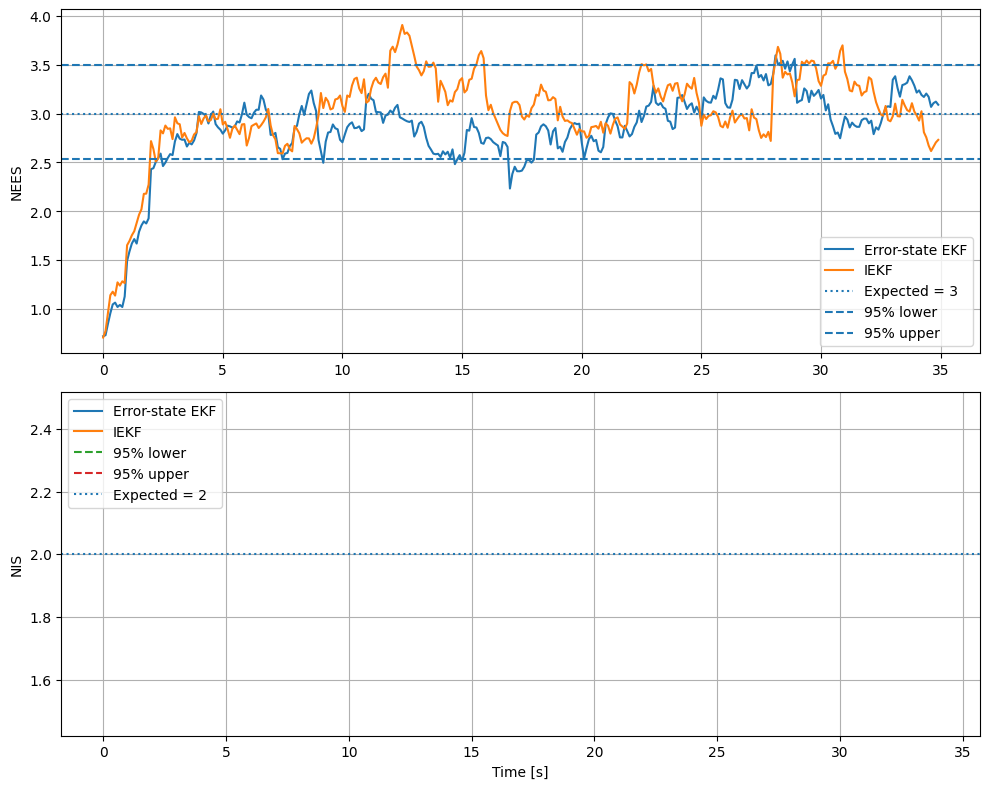

In [25]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
# plt.plot(t_arr, nees_avg_wf, label='World-frame EKF')
plt.plot(t_arr, nees_avg_bf, label='Error-state EKF')
plt.plot(t_arr, nees_avg_iekf, label='IEKF')
plt.axhline(nx, linestyle=':', label='Expected = 3')
plt.axhline(nees_lo, linestyle='--', label='95% lower')
plt.axhline(nees_hi, linestyle='--', label='95% upper')
plt.ylabel('NEES')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
# plt.plot(t_arr, nis_avg_wf, label='World-frame EKF')
plt.plot(t_arr, nis_avg_bf, label='Error-state EKF')
plt.plot(t_arr, nis_avg_iekf, label='IEKF')
plt.plot(t_arr, nis_lo, '--', label='95% lower')
plt.plot(t_arr, nis_hi, '--', label='95% upper')
plt.axhline(nz, linestyle=':', label='Expected = 2')
plt.ylabel('NIS')
plt.xlabel('Time [s]')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
summary = pd.DataFrame({
    "Filter": [ "Error-state EKF", "IEKF"],
    "time-avg NEES": [
        ## np.nanmean(nees_avg_wf),
        np.nanmean(nees_avg_bf),
        np.nanmean(nees_avg_iekf)
    ],
    "time-avg NIS": [
        ## np.nanmean(nis_avg_wf),
        np.nanmean(nis_avg_bf),
        np.nanmean(nis_avg_iekf)
    ]
})

print(summary)

            Filter  time-avg NEES  time-avg NIS
0  Error-state EKF       2.837228      1.980496
1             IEKF       3.005338      1.936877


# 4e

A good ranking is usually: IEKF > error-state EKF > world-frame EKF. The world-frame EKF keeps covariance in global coordinates, so its ellipse tends to miss the direction in which uncertainty grows with the vehicle motion. The error-state EKF and IEKF keep the uncertainty in body-frame coordinates, so after rotating to world coordinates their ellipse aligns better with the trajectory and better matches the local shape of the banana prior.

The banana distribution comes from the noncommutativity of translation and rotation on SE(2): uncertainty in heading changes how forward motion maps into world position. Working in the body frame mitigates this because the error is represented in coordinates attached to the vehicle, where the local perturbation stays closer to Gaussian and the dynamics are more natural. The key property to preserve is that the linearized A matrix should depend only on the commanded body velocity, not on the pose. That state-independence improves consistency and makes covariance propagation less sensitive to where the vehicle is on the trajectory.